In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install pytorch-lightning monai

import sys, torch
print("Python:", sys.version)
print("Torch:", torch.__version__, "CUDA available:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 115.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 74.8 MB/s eta 0:00:00
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch: 2.9.0+cu128 CUDA available: True


In [3]:
%cd /content/drive/MyDrive/PRIM

/content/drive/MyDrive/PRIM


In [4]:
import convnet3D_utils, inspect, os
print("convnet3D_utils file:", convnet3D_utils.__file__)
print("trainprostVQ exists:", os.path.exists("/content/drive/MyDrive/PRIM/trainprostVQ.py"))

convnet3D_utils file: /content/drive/MyDrive/PRIM/convnet3D_utils.py
trainprostVQ exists: True


In [5]:
!python -u trainprostVQ.py

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-02-18 16:45:35.937998: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-18 16:45:35.956743: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771433135.975999    3580 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771433135.982181    3580 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register facto

In [6]:
!python /content/drive/MyDrive/PRIM/data/Prostate/tokens.py


=== tokens_train ===
type: <class 'torch.Tensor'>
shape: (55, 12, 12, 4)
dtype: torch.int64
min/max: 0 30
#unique: 31
Saved: /content/drive/MyDrive/PRIM/data/Prostate/outputprostatefinal/tokens_plots/tokens_train_slice.png
Saved: /content/drive/MyDrive/PRIM/data/Prostate/outputprostatefinal/tokens_plots/tokens_train_hist.png

=== tokens_val ===
type: <class 'torch.Tensor'>
shape: (12, 12, 12, 4)
dtype: torch.int64
min/max: 0 29
#unique: 27
Saved: /content/drive/MyDrive/PRIM/data/Prostate/outputprostatefinal/tokens_plots/tokens_val_slice.png
Saved: /content/drive/MyDrive/PRIM/data/Prostate/outputprostatefinal/tokens_plots/tokens_val_hist.png

=== tokens_test ===
type: <class 'torch.Tensor'>
shape: (12, 12, 12, 4)
dtype: torch.int64
min/max: 0 29
#unique: 28
Saved: /content/drive/MyDrive/PRIM/data/Prostate/outputprostatefinal/tokens_plots/tokens_test_slice.png
Saved: /content/drive/MyDrive/PRIM/data/Prostate/outputprostatefinal/tokens_plots/tokens_test_hist.png

Ready. Figures in: /cont

In [7]:
import os, torch
root = "./data/Prostate/outputprostatefinal"
for fn in ["tokens_train.pt","tokens_val.pt","tokens_test.pt"]:
    p = os.path.join(root, fn)
    obj = torch.load(p, weights_only=False)
    tok = torch.as_tensor(obj).long().contiguous().cpu()
    torch.save(tok, p)
    print(fn, tok.shape, tok.dtype, tok.min().item(), tok.max().item())

tokens_train.pt torch.Size([55, 12, 12, 4]) torch.int64 0 30
tokens_val.pt torch.Size([12, 12, 12, 4]) torch.int64 0 29
tokens_test.pt torch.Size([12, 12, 12, 4]) torch.int64 0 29


In [8]:
!python -u train_token_prior.py

TRAIN: unique tokens = 31 / 32
bg_tok = 13 freq = 0.297506
[ep 000] loss=3.3119  val_loss=1.4602
[ep 001] loss=1.1043  val_loss=1.1754
[ep 002] loss=0.9465  val_loss=0.7567
[ep 003] loss=0.9073  val_loss=0.7371
[ep 004] loss=0.7098  val_loss=0.4883
[ep 005] loss=0.6760  val_loss=0.6275
[ep 006] loss=0.5374  val_loss=0.7255
[ep 007] loss=0.7182  val_loss=0.4438
[ep 008] loss=0.6412  val_loss=0.9046
[ep 009] loss=0.6303  val_loss=0.8479
saved samples tokens
[ep 010] loss=0.6572  val_loss=0.4163
[ep 011] loss=0.5754  val_loss=0.9269
[ep 012] loss=0.5554  val_loss=0.7207
[ep 013] loss=0.5015  val_loss=0.6733
[ep 014] loss=0.6998  val_loss=0.7903
[ep 015] loss=0.6520  val_loss=0.6874
[ep 016] loss=0.5841  val_loss=0.5113
[ep 017] loss=0.4808  val_loss=0.6365
[ep 018] loss=0.6039  val_loss=0.9461
[ep 019] loss=0.5716  val_loss=0.7037
saved samples tokens
[ep 020] loss=0.5065  val_loss=0.4279
Early stop: no mejora en 10 epochs. best_val=0.4163
Saved best samples tokens: ./data/Prostate/output

In [9]:
!python -u decode_samples.py

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-02-18 16:51:27.249294: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-18 16:51:27.269199: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771433487.292792    5778 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771433487.300491    5778 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register facto

In [10]:
import nibabel as nib, numpy as np
p = "./data/Prostate/outputprostatefinal/decoded_samples/sample_0.nii.gz"
arr = nib.load(p).get_fdata().astype(np.int16)
print("unique labels:", np.unique(arr))

unique labels: [0 1 2]


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Using ckpt: ./data/Prostate/outputprostatefinal/best_dice_epochepoch=01_diceval_dice=0.6530.ckpt
Generated sample: ./data/Prostate/outputprostatefinal/decoded_samples/sample_0.nii.gz (192, 192, 64) unique: [0 1 2]


Loading Data: 100%|██████████| 12/12 [00:00<00:00, 17482.34it/s]


Real label unique: [0 1 2]
Reconstruction unique: [0 1 2]
tok_real shape: (1, 12, 12, 4) tok_real min/max: 0 28
Saved: ./data/Prostate/outputprostatefinal/decoded_samples/recon_from_real_0.nii.gz
Saved: ./data/Prostate/outputprostatefinal/decoded_samples/real_preprocessed_0.nii.gz
Dice recon vs real (class 1): 0.6224
Dice recon vs real (class 2): 0.7928


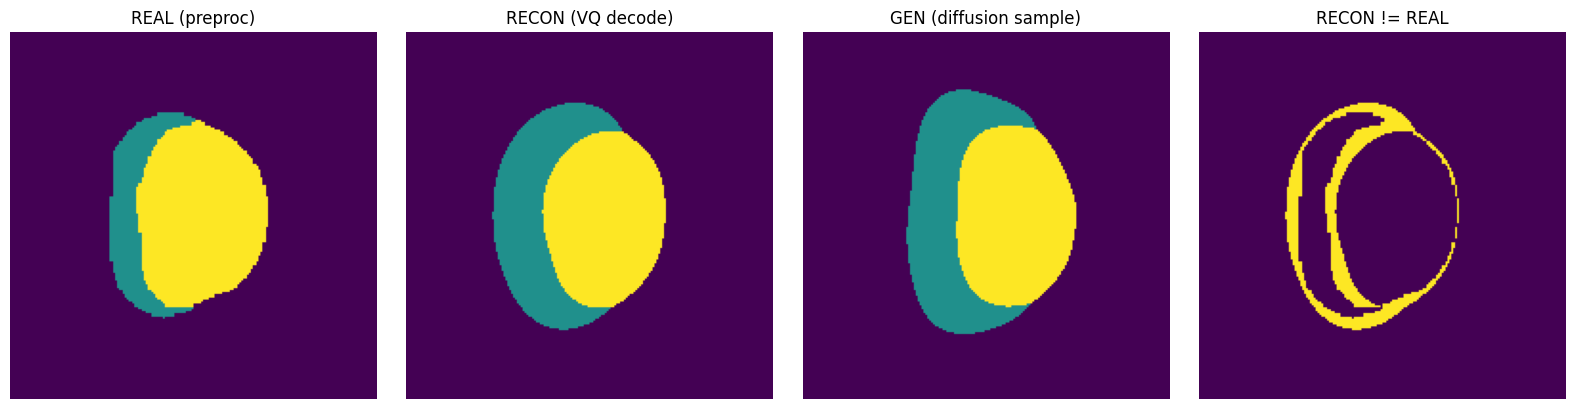

Latest sampled tokens: ./data/Prostate/outputprostatefinal/samples_tokens_ep019.pt shape: (2, 12, 12, 4)
Token match fraction (gen[0] vs real[0]): 0.4236 (1.0 sería sospechoso)


In [11]:
import os, glob
import numpy as np
import torch
import nibabel as nib
import matplotlib.pyplot as plt

from trainprostVQ import Net, ProstateDataset

# ----------------------------
# Config
# ----------------------------
root = "./data/Prostate/outputprostatefinal"
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1) Cargar ckpt del VQUNet (el mismo criterio que decode_samples.py)
ckpts = sorted(glob.glob(os.path.join(root, "best_dice_epoch*.ckpt")))
assert len(ckpts) > 0, f"No encontré checkpoints best_dice en {root}"
ckpt_path = ckpts[-1]
print("Using ckpt:", ckpt_path)

net = Net.load_from_checkpoint(ckpt_path, strict=False).to(device)
net.eval()

# 2) Elegir un sample generado por difusión ya decodificado (NIfTI)
gen_dir = os.path.join(root, "decoded_samples")
gen_niis = sorted(glob.glob(os.path.join(gen_dir, "sample_*.nii.gz")))
assert len(gen_niis) > 0, f"No encontré sample_*.nii.gz en {gen_dir}"
gen_path = gen_niis[0]   # cambia el índice si quieres otro
gen = nib.load(gen_path).get_fdata().astype(np.uint8)  # [H,W,D]
print("Generated sample:", gen_path, gen.shape, "unique:", np.unique(gen))

# 3) Tomar 1 ejemplo REAL (preprocesado) del dataset y reconstruirlo vía tokens
#    OJO: usa datatype='val' para evitar augmentations aleatorias.
ds = ProstateDataset("./validation.csv", datatype="val")
item = ds[0]  # cambia índice si quieres otro

real = item["label"]
# MONAI puede devolver MetaTensor; lo convertimos a Tensor "normal"
if hasattr(real, "as_tensor"):
    real = real.as_tensor()
real = torch.as_tensor(real).to(device)  # shape típica: [1,192,192,64] o [192,192,64]

if real.ndim == 3:
    real = real.unsqueeze(0)  # [1,H,W,D]
real_np = real.squeeze(0).detach().cpu().numpy().astype(np.uint8)

# 3a) Encode -> tokens reales
with torch.no_grad():
    x = net.build_x(real)                       # input multi-canal (one-hot + boundary si aplica)
    tok_real = net.encode_x(x, add_noise=False) # [B,12,12,4] en tu config actual
    recon = net.decode_indices_to_seg(tok_real) # [B,1,192,192,64]

recon_np = recon.squeeze(0).squeeze(0).detach().cpu().numpy().astype(np.uint8)

print("Real label unique:", np.unique(real_np))
print("Reconstruction unique:", np.unique(recon_np))
print("tok_real shape:", tuple(tok_real.shape), "tok_real min/max:", int(tok_real.min()), int(tok_real.max()))

# 3b) Guardar NIfTI de la reconstrucción real para inspección en 3D Slicer/ITK-SNAP
out_recon = os.path.join(gen_dir, "recon_from_real_0.nii.gz")
out_real  = os.path.join(gen_dir, "real_preprocessed_0.nii.gz")
nib.save(nib.Nifti1Image(recon_np, np.eye(4)), out_recon)
nib.save(nib.Nifti1Image(real_np,  np.eye(4)), out_real)
print("Saved:", out_recon)
print("Saved:", out_real)

# ----------------------------
# Métricas simples
# ----------------------------
def dice_bin(a, b):
    a = a.astype(bool); b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    den = a.sum() + b.sum()
    return (2.0 * inter / den) if den > 0 else 1.0

# Dice por clase (clases 1 y 2; clase 0 suele dominar por fondo)
for c in [1, 2]:
    d = dice_bin(real_np == c, recon_np == c)
    print(f"Dice recon vs real (class {c}): {d:.4f}")

# ----------------------------
# Comparación visual rápida (misma rebanada)
# ----------------------------
z = real_np.shape[-1] // 2  # corte axial medio
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(real_np[:, :, z]);  ax[0].set_title("REAL (preproc)"); ax[0].axis("off")
ax[1].imshow(recon_np[:, :, z]); ax[1].set_title("RECON (VQ decode)"); ax[1].axis("off")
ax[2].imshow(gen[:, :, z]);      ax[2].set_title("GEN (diffusion sample)"); ax[2].axis("off")

# diferencia simple (dónde cambian labels)
diff = (recon_np[:, :, z] != real_np[:, :, z]).astype(np.uint8)
ax[3].imshow(diff); ax[3].set_title("RECON != REAL"); ax[3].axis("off")
plt.tight_layout()
plt.show()

# ----------------------------
# (Opcional) Comparar tokens sampleados vs tokens reales para verificar que NO son copia
# ----------------------------
tok_samples = sorted(glob.glob(os.path.join(root, "samples_tokens_ep*.pt")))
if len(tok_samples) > 0:
    tok_path = tok_samples[-1]
    tok_gen = torch.load(tok_path, map_location="cpu").long()  # [B,12,12,4]
    tg = tok_gen[0].numpy()
    tr = tok_real.squeeze(0).detach().cpu().numpy()
    same_frac = (tg == tr).mean()
    print("Latest sampled tokens:", tok_path, "shape:", tuple(tok_gen.shape))
    print(f"Token match fraction (gen[0] vs real[0]): {same_frac:.4f} (1.0 sería sospechoso)")
else:
    print("No encontré samples_tokens_ep*.pt para comparar tokens directamente.")


In [12]:
import os, glob, torch

root = "./data/Prostate/outputprostatefinal"
K = 32

tok_train = torch.load(os.path.join(root, "tokens_train.pt"))
hist_train = torch.bincount(tok_train.view(-1), minlength=K).float()
p_train = hist_train / hist_train.sum()
bg_tok = int(torch.argmax(hist_train))

print("TRAIN: unique tokens =", int((hist_train>0).sum()), "/", K)
print("TRAIN: bg token id =", bg_tok, "freq =", float(p_train[bg_tok]))

# último sample de difusión
samp_path = sorted(glob.glob(os.path.join(root, "samples_tokens_ep*.pt")))[-1]
tok_gen = torch.load(samp_path)
hist_gen = torch.bincount(tok_gen.view(-1), minlength=K).float()
p_gen = hist_gen / hist_gen.sum()

print("GEN:", os.path.basename(samp_path))
print("GEN: unique tokens =", int((hist_gen>0).sum()), "/", K)
print("GEN: bg token freq =", float(p_gen[bg_tok]))

# top-5 tokens
topv, topi = torch.topk(p_gen, k=5)
print("GEN top5 (token, freq):", [(int(i), float(v)) for v,i in zip(topv, topi)])

TRAIN: unique tokens = 31 / 32
TRAIN: bg token id = 13 freq = 0.29750630259513855
GEN: samples_tokens_ep019.pt
GEN: unique tokens = 6 / 32
GEN: bg token freq = 0.2256944477558136
GEN top5 (token, freq): [(6, 0.6302083134651184), (13, 0.2256944477558136), (11, 0.0763888880610466), (23, 0.0651041641831398), (12, 0.0017361111240461469)]


In [13]:
import nibabel as nib, numpy as np, glob, os

root = "./data/Prostate/outputprostatefinal/decoded_samples"
p = sorted(glob.glob(os.path.join(root, "sample_*.nii.gz")))[0]
seg = nib.load(p).get_fdata().astype(np.int16)

vals, counts = np.unique(seg, return_counts=True)
freq = counts / counts.sum()
print("Label frequencies (generated):", dict(zip(vals.tolist(), freq.tolist())))

Label frequencies (generated): {0: 0.9153938293457031, 1: 0.03380160861545139, 2: 0.05080456203884549}


In [14]:
p_real = os.path.join(root, "real_preprocessed_0.nii.gz")
real = nib.load(p_real).get_fdata().astype(np.int16)
vals, counts = np.unique(real, return_counts=True)
freq = counts / counts.sum()
print("Label frequencies (real):", dict(zip(vals.tolist(), freq.tolist())))

Label frequencies (real): {0: 0.9424349466959635, 1: 0.01957914564344618, 2: 0.037985907660590276}


In [15]:
import nibabel as nib, numpy as np, os

root = "./data/Prostate/outputprostatefinal/decoded_samples"
a = nib.load(os.path.join(root,"sample_0.nii.gz")).get_fdata().astype(np.int16)
b = nib.load(os.path.join(root,"sample_1.nii.gz")).get_fdata().astype(np.int16)
print("voxel match fraction:", (a==b).mean())

voxel match fraction: 0.9845797220865885


In [16]:
import nibabel as nib, numpy as np, os

root = "./data/Prostate/outputprostatefinal/decoded_samples"
a = nib.load(os.path.join(root,"sample_0.nii.gz")).get_fdata().astype(np.int16)
b = nib.load(os.path.join(root,"sample_1.nii.gz")).get_fdata().astype(np.int16)

mask_fg = (a>0) | (b>0)
match_all = (a==b).mean()
match_fg  = (a[mask_fg]==b[mask_fg]).mean() if mask_fg.any() else 1.0

def dice_bin(x, y):
    x = x.astype(bool); y = y.astype(bool)
    inter = np.logical_and(x,y).sum()
    den = x.sum()+y.sum()
    return (2*inter/den) if den>0 else 1.0

dice_fg = dice_bin(a>0, b>0)

print("match_all:", match_all)
print("match_fg :", match_fg)
print("dice_fg  :", dice_fg)

match_all: 0.9845797220865885
match_fg : 0.8208114976949447
dice_fg  : 0.9172319638209822


In [17]:
root = "./data/Prostate/outputprostatefinal"
train = torch.load(os.path.join(root, "tokens_train.pt")).long()         # [N,12,12,4]
gen   = torch.load(os.path.join(root, "samples_tokens_best.pt")).long() # [B,12,12,4]

train_flat = train.view(train.shape[0], -1)
gen_flat   = gen.view(gen.shape[0], -1)

for b in range(gen.shape[0]):
    eq = (train_flat == gen_flat[b].unsqueeze(0)).float().mean(dim=1)
    m, idx = torch.max(eq, dim=0)
    print(f"gen[{b}] nearest train idx={int(idx)} match={float(m):.4f}")

gen[0] nearest train idx=43 match=0.7882
gen[1] nearest train idx=43 match=0.7691
gen[2] nearest train idx=10 match=0.7483
gen[3] nearest train idx=10 match=0.7847
gen[4] nearest train idx=7 match=0.7812
gen[5] nearest train idx=10 match=0.7674
gen[6] nearest train idx=7 match=0.7743
gen[7] nearest train idx=7 match=0.7917
